In [1]:
import originpro as op
import numpy as np
import pandas as pd

import os
# Very useful, especially during development, when you are
# liable to have a few uncaught exceptions.
# Ensures that the Origin instance gets shut down properly.
# Note: only applicable to external Python.
import sys
def origin_shutdown_exception_hook(exctype, value, traceback):
    '''Ensures Origin gets shut down if an uncaught exception'''
    op.exit()
    sys.__excepthook__(exctype, value, traceback)
if op and op.oext:
    sys.excepthook = origin_shutdown_exception_hook

import  re
# Set Origin instance visibility.
# Important for only external Python.
# Should not be used with embedded Python.
if op.oext:
    op.set_show(True)


# Example of opening a project and reading data.

# We'll open the Tutorial Data.opju project that ships with Origin.
src_opju = r"C:\usrspace\mywork\main.opju"   # <— 用绝对路径；注意路径和文件名是否正确
print("File exists? ", os.path.exists(src_opju))
ok = op.open(file=src_opju)
print("Project opened? ", ok)
import draw.pymatlab2.origin_function.csv2origin as csv2origin

import draw.pymatlab2.origin_function.fillgap as fillgap
from config import DATA_DIR,INPUT_DIR
from pathlib import Path

File exists?  True
Project opened?  True


测试

In [2]:

# ===== 2) 列出所有页面类型，看看有没有工作簿 =====
wbooks = list(op.pages('w'))   # 所有工作簿（Worksheet Book）
mbks   = list(op.pages('m'))   # 所有矩阵簿（Matrix Book）
graphs = list(op.pages('g'))   # 所有图页（Graph），仅排查
notes  = list(op.pages('n'))   # 所有Notes，仅排查

print("#Workbooks:", len(wbooks), "| #MatrixBooks:", len(mbks), "| #Graphs:", len(graphs), "| #Notes:", len(notes))

# ===== 3) 如果有工作簿：打印每个工作簿下所有工作表名 =====
for wb in wbooks:
    sheet_names = [wks.name for wks in wb]
    print(f"[{wb.name}] -> {sheet_names}")

# ===== 4) 如果是矩阵簿：打印矩阵表名（有些项目只有矩阵簿，没有工作簿）=====
for mb in mbks:
    ms_names = [ms.name for ms in mb]
    print(f"[{mb.name}] (Matrix) -> {ms_names}")

# ===== 5) 若你想强行拿到第一个工作簿并遍历 =====
if wbooks:
    wb = wbooks[0]
    print("Active to:", wb.name)
    wb.activate()  # 让它成为激活窗口
    for wks in wb:
        print("Sheet:", wks.name)

#Workbooks: 1 | #MatrixBooks: 0 | #Graphs: 10 | #Notes: 0
[Book1] -> ['pending_edges_ttb10', 'pending_edges_ttb20', 'pending_edges_ttb30', 'pending_edges_ttb40', 'pending_edges_ttb50']
Active to: Book1
Sheet: pending_edges_ttb10
Sheet: pending_edges_ttb20
Sheet: pending_edges_ttb30
Sheet: pending_edges_ttb40
Sheet: pending_edges_ttb50


In [4]:

# test for a single file
time_2_build = 40
TIME_2_BUILD = time_2_build
from pathlib import Path
# 默认用 "topology_{TIME_2_BUILD}"，也允许用环境变量 TOPOLOGY_VERSION 覆盖
VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{TIME_2_BUILD}")

FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"
filename = f"pending_edges_ttb{TIME_2_BUILD}"
FIGURE_DIR = Path(FIGURE_DIR)           # 确保是 Path
csv1_path = FIGURE_DIR / f"{filename}.csv"

csv2origin.csv_to_origin(csv1_path, book="Book1", sheet=filename, clear=True)

In [54]:
#when we finished the write to the origin ,we first need fill the gap
# mod_gap.py
from __future__ import annotations
import pandas as pd
from typing import Iterable, Optional, Sequence
import draw.pymatlab2.origin_function.csv2origin as csv2origin

import draw.pymatlab2.origin_function.fillgap as fillgap


fillgap.origin_fill_time_gaps(
    book="Book1",
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)

,time,pending_edges
0,0,41
1,1,41
2,2,41
3,3,41
4,4,41
...,...,...
21889,21889,21
21890,21890,21
21891,21891,21
21892,21892,21


## 读入pending edge


In [3]:
TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
for ttb in TTB_VALUES:
    VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"pending_edges_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book="Book1", sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的
    fillgap.origin_fill_time_gaps(
    book="Book1",
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)


###  平均无建链时间占比
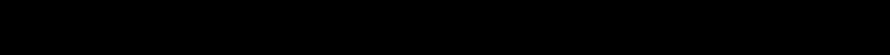
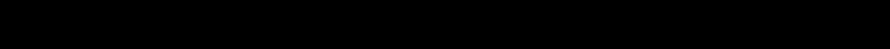
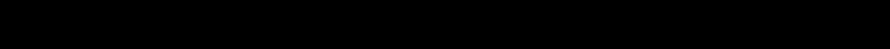

In [5]:
# 不考虑缺口：仅按观测到的连续行里 pending_edges==0 计算窗口
# 仅遍历 Book1

import draw.pymatlab2.origin_function.write2origin as write2origin

MIN_WINDOW_LEN = 1    # 连续0窗口的最小长度（行数/秒数）
results = []


TARGET_BOOK = 'Book1'      # 只在 Book1 里统计
OUT_SHEET = 'zero_stable time and Proportion'   # 去掉尾部空格，避免重名问题

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"未找到工作簿 '{TARGET_BOOK}'，请确认数据就在此书中。")

for wks in bk:
    nm = wks.name
    if not nm.startswith('pending_edges_'):
        continue

    # ===== 读取（Long Name 作为表头）=====
    df = wks.to_df(head='L')
    if not {'time','pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [Book1] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [Book1] {nm}")
        continue

    # ===== 未建链占比：edge==0 计为“未建链”；NaN 按 0 处理；不考虑缺口 =====
    observed_seconds = int(len(df))                             # 分母：观测到的总时长（行数）
    no_link_seconds  = int(df['pending_edges'].fillna(0).eq(0).sum())  # 分子：edge==0 的时长
    no_link_ratio    = (no_link_seconds / observed_seconds) if observed_seconds > 0 else 0.0
    no_link_ratio_pct = round(no_link_ratio * 100.0, 4)

    print(f"[Book1] {nm} | no-link={no_link_seconds}s / {observed_seconds}s = {no_link_ratio_pct:.2f}%")

    results.append({
        'book': 'Book1',
        'sheet': nm,
        'time_min': int(df['time'].min()),
        'time_max': int(df['time'].max()),
        'observed_seconds': observed_seconds,
        'no_link_seconds': no_link_seconds,
        'no_link_ratio': round(no_link_ratio, 6),
        'no_link_ratio_pct': no_link_ratio_pct,
    })

# ===== 汇总并写回 Origin(写到 Book1 -> "stable time and Proportion") =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s):
        try:
            return int(''.join(ch for ch in s if ch.isdigit()))
        except Exception:
            return None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'no_link_ratio_pct', 'no_link_seconds', 'observed_seconds']

    print("\n=== SUMMARY (No-Link Ratio) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet('Book1',  OUT_SHEET,
                                   clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print("写入完成 -> [Book1] stable time and Proportion")
else:
    print("没有匹配到 pending_edges_* 的工作表。")


[Book1] pending_edges_ttb10 | no-link=18845s / 21894s = 86.07%
[Book1] pending_edges_ttb20 | no-link=15985s / 21894s = 73.01%
[Book1] pending_edges_ttb30 | no-link=13309s / 21894s = 60.79%
[Book1] pending_edges_ttb40 | no-link=10763s / 21894s = 49.16%
[Book1] pending_edges_ttb50 | no-link=8560s / 21894s = 39.10%
[Book1] pending_edges_ttb60 | no-link=6435s / 21894s = 29.39%
[Book1] pending_edges_ttb70 | no-link=4316s / 21894s = 19.71%
[Book1] pending_edges_ttb80 | no-link=2361s / 21894s = 10.78%
[Book1] pending_edges_ttb90 | no-link=868s / 21894s = 3.96%
[Book1] pending_edges_ttb100 | no-link=805s / 21894s = 3.68%
[Book1] pending_edges_ttb110 | no-link=670s / 21894s = 3.06%
[Book1] pending_edges_ttb120 | no-link=576s / 21894s = 2.63%
[Book1] pending_edges_ttb130 | no-link=437s / 21894s = 2.00%
[Book1] pending_edges_ttb140 | no-link=345s / 21894s = 1.58%


KeyError: 'ttb'

### 无建链稳定时长
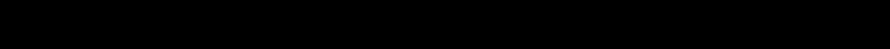

[Book1] pending_edges_ttb10 | zero-segs=135 | avg=139.59s | sum=18845s | max=168s | ratio=86.07%
[Book1] pending_edges_ttb20 | zero-segs=133 | avg=120.19s | sum=15985s | max=156s | ratio=73.01%
[Book1] pending_edges_ttb30 | zero-segs=133 | avg=100.07s | sum=13309s | max=146s | ratio=60.79%
[Book1] pending_edges_ttb40 | zero-segs=129 | avg=83.43s | sum=10763s | max=136s | ratio=49.16%
[Book1] pending_edges_ttb50 | zero-segs=128 | avg=66.88s | sum=8560s | max=126s | ratio=39.10%
[Book1] pending_edges_ttb60 | zero-segs=125 | avg=51.48s | sum=6435s | max=116s | ratio=29.39%
[Book1] pending_edges_ttb70 | zero-segs=121 | avg=35.67s | sum=4316s | max=106s | ratio=19.71%
[Book1] pending_edges_ttb80 | zero-segs=119 | avg=19.84s | sum=2361s | max=96s | ratio=10.78%
[Book1] pending_edges_ttb90 | zero-segs=23 | avg=37.74s | sum=868s | max=86s | ratio=3.96%
[Book1] pending_edges_ttb100 | zero-segs=14 | avg=57.50s | sum=805s | max=76s | ratio=3.68%
[Book1] pending_edges_ttb110 | zero-segs=13 | avg=5

In [11]:


TARGET_BOOK = 'Book1'
OUT_SHEET   = 'average_time_stable'  # 结果写到这个表（修正拼写）
MIN_WINDOW_LEN_SEC = 1               # 过滤过短片段（单位：秒）
IGNORE_FIRST_SEG = True              # 是否忽略首段

def estimate_step_seconds(t_arr: np.ndarray) -> int:
    """估计时间步长（多数情况下为 1 秒）。"""
    if t_arr.size < 2:
        return 1
    diffs = np.diff(t_arr)
    pos = diffs[diffs > 0]
    if pos.size == 0:
        return 1
    # 众数
    mode_val = int(pd.Series(pos).mode().iat[0])
    return max(1, mode_val)

def calculate(df: pd.DataFrame) -> tuple[float, int, int, int]:
    """
    计算平均/最大/最小“无建链稳定时长”（秒）以及片段数。
    片段定义：pending_edges==0 的极大连续区间（按 time 序列的值连续性，不按行数）。
    """
    # 预处理：只取需要的两列，转数值、去空、按 time 排序
    s = df[['time', 'pending_edges']].copy()
    s['time'] = pd.to_numeric(s['time'], errors='coerce')
    s['pending_edges'] = pd.to_numeric(s['pending_edges'], errors='coerce').fillna(0)
    s = s.dropna(subset=['time'])
    if s.empty:
        return 0.0, 0, 0, 0

    s['time'] = s['time'].astype(int)
    s = s.sort_values('time')
    t_arr = s['time'].to_numpy()
    e_arr = s['pending_edges'].astype(int).to_numpy()

    step = estimate_step_seconds(t_arr)

    # 遍历，抽取 pending_edges==0 的极大连续段（按 time 连续性）
    segments: list[tuple[int, int]] = []
    in_zero = (e_arr[0] == 0)
    seg_start = t_arr[0] if in_zero else None
    last_t = t_arr[0]

    for t, e in zip(t_arr[1:], e_arr[1:]):
        # 只要状态没变，就继续；状态变化时收段/开段
        if e == 0 and not in_zero:
            # False -> True：开始新段
            in_zero = True
            seg_start = t
        elif e != 0 and in_zero:
            # True -> False：收尾一段
            in_zero = False
            seg_end = last_t
            segments.append((seg_start, seg_end))
            seg_start = None
        last_t = t

    # 末尾收尾
    if in_zero and seg_start is not None:
        segments.append((seg_start, last_t))

    # 可选：忽略首段
    if IGNORE_FIRST_SEG and len(segments) >= 1:
        segments = segments[1:]

    if not segments:
        return 0.0, 0, 0, 0

    # 计算各段长度（秒）
    lengths = [max(0, (end - start) + step) for (start, end) in segments]
    # 过滤过短片段
    lengths = [L for L in lengths if L >= MIN_WINDOW_LEN_SEC]

    if not lengths:
        return 0.0, 0, 0, 0

    K = len(lengths)
    avg_len = sum(lengths) / K
    max_len = max(lengths)
    min_len = min(lengths)
    return float(avg_len), int(max_len), int(min_len), int(K)

# ============ 主流程 ============
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('pending_edges_'):
        continue

    # 读取（Long Name 为表头）
    df = wks.to_df(head='L')
    if not {'time','pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    avg_len, max_len, min_len, seg_cnt = calculate(df)

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'average_stable_time_sec': avg_len,
        'max_stable_time_sec': max_len,
        'min_stable_time_sec': min_len,
        'segments': seg_cnt,
    })

# 汇总并写回 Origin
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s):
        try:
            return int(''.join(ch for ch in s if ch.isdigit()))
        except Exception:
            return None

    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'average_stable_time_sec', 'max_stable_time_sec',
            'min_stable_time_sec', 'segments']

    print("\n=== SUMMARY (Average Zero-Stable Length, seconds) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET,
                                   clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")



=== SUMMARY (Average Zero-Stable Length, seconds) ===
 ttb  average_stable_time_sec  max_stable_time_sec  min_stable_time_sec  segments
  10               140.462687                  168                    1       134
  20               121.000000                  156                    2       132
  30               100.803030                  146                    1       132
  40                83.367188                  136                    2       128
  50                66.834646                  126                    4       127
  60                51.475806                  116                    1       124
  70                35.700000                  106                    1       120
  80                19.906780                   96                    7       118
  90                37.272727                   86                    1        22
 100                59.000000                   76                    8        13
 110                53.500000              

### 平均建链条数




meth1:

In [6]:
TARGET_BOOK = 'Book1'
OUT_SHEET   = 'avg_switches'   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('pending_edges_'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 平均切换条数（每秒平均）=====
    observed_seconds = int(len(df))                        # T
    pe = df['pending_edges'].fillna(0)                     # L_i（NaN 记为 0）
    sum_link = float(pe.sum())                             # Σ L_i
    avg_link = sum_link / observed_seconds if observed_seconds > 0 else 0.0  # ΣL_i / T

    # 参考指标（可选）
    max_link = int(pe.max()) if len(pe) else 0
    med_link = float(pe.median()) if len(pe) else 0.0

    print(f"[{TARGET_BOOK}] {nm} | avg_link={avg_link:.6f}  "
          f"(sum={sum_link:.0f}, T={observed_seconds}, max={max_link}, median={med_link:.2f})")

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'time_min': int(df['time'].min()),
        'time_max': int(df['time'].max()),
        'observed_seconds': observed_seconds,   # T
        'sum_link': round(sum_link, 4),         # Σ L_i
        'avg_link': round(avg_link, 6),         # 平均切换条数（每秒）
        'max_link': max_link,
        'median_link': round(med_link, 4),
    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s):
        try:
            return int(''.join(ch for ch in s if ch.isdigit()))
        except Exception:
            return None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'avg_link', 'sum_link', 'observed_seconds', 'max_link', 'median_link']

    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

[Book1] pending_edges_ttb10 | avg_link=1.826528  (sum=39990, T=21894, max=41, median=0.00)
[Book1] pending_edges_ttb20 | avg_link=3.652142  (sum=79960, T=21894, max=43, median=0.00)
[Book1] pending_edges_ttb30 | avg_link=5.474102  (sum=119850, T=21894, max=41, median=0.00)
[Book1] pending_edges_ttb40 | avg_link=7.285695  (sum=159513, T=21894, max=41, median=1.00)
[Book1] pending_edges_ttb50 | avg_link=9.087101  (sum=198953, T=21894, max=41, median=2.00)
[Book1] pending_edges_ttb60 | avg_link=10.859277  (sum=237753, T=21894, max=41, median=5.00)
[Book1] pending_edges_ttb70 | avg_link=12.626884  (sum=276453, T=21894, max=41, median=6.00)
[Book1] pending_edges_ttb80 | avg_link=14.414588  (sum=315593, T=21894, max=41, median=7.00)
[Book1] pending_edges_ttb90 | avg_link=16.200466  (sum=354693, T=21894, max=47, median=21.00)
[Book1] pending_edges_ttb100 | avg_link=18.030191  (sum=394753, T=21894, max=50, median=23.00)
[Book1] pending_edges_ttb110 | avg_link=19.822006  (sum=433983, T=21894, m

mthod2：将p1 p2分开来

In [12]:
TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
BOOKname = "Book2"
for ttb in TTB_VALUES:
    VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"p1_pending_edges_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的
    fillgap.origin_fill_time_gaps(
    book=BOOKname,
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)
    filename = f"p2_pending_edges_ttb{ttb}"
    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的
    fillgap.origin_fill_time_gaps(
    book=BOOKname,
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)


这里的算法，指的是关于处理p1 p2 pending edge的对比

In [24]:
# 该代码是不用的
TARGET_BOOK = 'Book2'
OUT_SHEET   = 'avg_switches_P1'   # 结果写到这个表
import  re
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('p1_pending_edges_'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 平均切换条数（每秒平均）=====
    observed_seconds = int(len(df))                        # T
    pe = df['pending_edges'].fillna(0)                     # L_i（NaN 记为 0）
    sum_link = float(pe.sum())                             # Σ L_i
    avg_link = sum_link / observed_seconds if observed_seconds > 0 else 0.0  # ΣL_i / T

    # 参考指标（可选）


    print(f"[{TARGET_BOOK}] {nm} | avg_link={avg_link:.6f}  "
          f"(sum={sum_link:.0f}, T={observed_seconds}, max={max_link}, median={med_link:.2f})")

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'time_min': int(df['time'].min()),
        'time_max': int(df['time'].max()),
        'observed_seconds': observed_seconds,   # T
        'sum_link': round(sum_link, 4),         # Σ L_i
        'avg_link': round(avg_link, 6),         # 平均切换条数（每秒）

    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s: str):
        m = re.search(r'(?<=ttb)\s*(\d+)\s*$', s)  # 优先匹配 "...ttbXX" 末尾
        if m:
            return int(m.group(1))
        m2 = re.search(r'(\d+)\s*$', s)            # 兜底：取末尾数字
        return int(m2.group(1)) if m2 else None



    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'avg_link', 'sum_link', 'observed_seconds',  ]

    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

[Book2] p1_pending_edges_ttb10 | avg_link=1.769800  (sum=38748, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb20 | avg_link=3.531013  (sum=77308, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb30 | avg_link=5.262172  (sum=115210, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb40 | avg_link=6.979675  (sum=152813, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb50 | avg_link=8.682927  (sum=190104, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb60 | avg_link=10.367224  (sum=226980, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb70 | avg_link=12.040742  (sum=263620, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb80 | avg_link=13.705125  (sum=300060, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb90 | avg_link=15.324290  (sum=335510, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb100 | avg_link=16.987759  (sum=371930, T=21894, max=50, median=27.00)
[Book2] p1_pending_edges_ttb110 | av

In [26]:
 # -*- coding: utf-8 -*-
 # 主要是用这段代码
import re
import pandas as pd
import originpro as op
from draw.pymatlab2.origin_function import write2origin

TARGET_BOOK = 'Book2'
OUT_SHEET   = 'avg_switches_P1_P2'   # 一张表里放 p1/p2 的平均值

def _pick_ttb(name: str):
    """从工作表名中抽取末尾的 ttb 数字：...ttb60 -> 60"""
    m = re.search(r'(?<=ttb)\s*(\d+)\s*$', name)
    if m:
        return int(m.group(1))
    m2 = re.search(r'(\d+)\s*$', name)  # 兜底
    return int(m2.group(1)) if m2 else None

def _avg_switches_from_df(df: pd.DataFrame) -> float:
    """计算每秒平均 pending_edges（ΣL_i / T）。"""
    s = df[['time', 'pending_edges']].copy()
    s['time'] = pd.to_numeric(s['time'], errors='coerce')
    s['pending_edges'] = pd.to_numeric(s['pending_edges'], errors='coerce')
    s = s.dropna(subset=['time'])
    if s.empty:
        return float('nan')
    s['time'] = s['time'].astype(int)
    s = s.sort_values('time')
    T = int(len(s))
    if T == 0:
        return float('nan')
    pe = s['pending_edges'].fillna(0)
    return float(pe.sum()) / T

def _collect_avg_by_prefix(bk, prefix: str) -> dict[int, float]:
    """遍历以 prefix 开头的工作表，返回 {ttb: avg}。"""
    out = {}
    for wks in bk:
        nm = wks.name
        if not nm.startswith(prefix):
            continue
        df = wks.to_df(head='L')
        if not {'time','pending_edges'}.issubset(df.columns):
            continue
        ttb = _pick_ttb(nm)
        if ttb is None:
            continue
        out[ttb] = _avg_switches_from_df(df)
    return out

# ===== 主流程 =====
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

p1_map = _collect_avg_by_prefix(bk, 'p1_pending_edges_')
p2_map = _collect_avg_by_prefix(bk, 'p2_pending_edges_')

# 合并到一张表（按 ttb 排序）
ttbs = sorted(set(p1_map) | set(p2_map))
rows = []
for t in ttbs:
    rows.append({
        'ttb': t,
        'avg_link_p1': float(p1_map.get(t, float('nan'))),
        'avg_link_p2': float(p2_map.get(t, float('nan'))),
    })
df_out = pd.DataFrame(rows).sort_values('ttb')

# 写回 Origin
ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
ws.from_df(df_out[['ttb', 'avg_link_p1', 'avg_link_p2']])

print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
print(df_out.to_string(index=False))


写入完成 -> [Book2] avg_switches_P1_P2
 ttb  avg_link_p1  avg_link_p2
  10     1.769800     0.059671
  20     3.531013     0.127414
  30     5.262172     0.222927
  40     6.979675     0.321899
  50     8.682927     0.425147
  60    10.367224     0.517584
  70    12.040742     0.616556
  80    13.705125     0.746277
  90    15.324290     0.921639
 100    16.987759     1.096522
 110    18.616973     1.267560
 120    20.197817     1.476987
 130    21.806933     1.678774
 140    23.433041     1.850197


here ,we solve the all_inter_edge.
这个就是稳定建联图。


In [2]:
TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
BOOKname = "Book3"
for ttb in TTB_VALUES:
    VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"topology_snapshot_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的


In [7]:
# 不考虑缺口：仅按观测到的连续行里 pending_edges==0 计算窗口
# 仅遍历 Book1

import draw.pymatlab2.origin_function.write2origin as write2origin

MIN_WINDOW_LEN = 1    # 连续0窗口的最小长度（行数/秒数）
results = []


TARGET_BOOK = 'Book2'      # 只在 Book1 里统计
OUT_SHEET = 'topology_change_summary2'   # 去掉尾部空格，避免重名问题

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"未找到工作簿 '{TARGET_BOOK}'，请确认数据就在此书中。")

sheetname  = "topology_change_summary"
wks = op.find_sheet('w', '[TARGET_BOOK]sheetname')


In [3]:
import numpy as np
import pandas as pd
import originpro as op
import draw.pymatlab2.origin_function.write2origin as write2origin

TARGET_BOOK = 'Book3'
SRC_SHEET   = 'topology_snapshot_ttb60'    # 源表：含 t / link_count / changed


# ===== 1) 用你要求的方式找到源表 =====
wks = op.find_sheet('w', f'[{TARGET_BOOK}]{SRC_SHEET}')
if wks is None:
    raise RuntimeError(f"在工作簿 '{TARGET_BOOK}' 中未找到工作表 '{SRC_SHEET}'")

# ===== 2) 读取数据（用 Long Name 作列名）=====
df = wks.to_df(head='L')
need = {'t','link_count','changed'}
if not need.issubset(df.columns):
    raise RuntimeError(f"源表缺列，需包含 {need}，实际为：{set(df.columns)}")

# 规范化
df['t']          = pd.to_numeric(df['t'], errors='coerce')
df['link_count'] = pd.to_numeric(df['link_count'], errors='coerce')
df['changed']    = pd.to_numeric(df['changed'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['t','link_count']).sort_values('t').reset_index(drop=True)

# ===== 3) 计算三列：stable_line / change_line / change_mark =====


In [5]:
import  draw.pymatlab2.origin_function.get_qujian as get_qujian




# df 为包含 t / link_count / changed 的 DataFrame
qujian = get_qujian.extract_stable_intervals(df, rep_stat="mean")

# print(f"共找到 {len(qujian)} 个稳定区间")
# for i, q in enumerate(qujian, 1):
#     print(f"区间{i}: t∈{q.interval}, 平均边数={q.edges:.1f}, 时长={q.length:.1f}")

# 求平均稳定时长
avg_len = np.mean([q.length for q in qujian])
print(f"平均稳定拓扑时长: {avg_len:.2f}")



平均稳定拓扑时长: 49.71


In [20]:
import importlib
importlib.reload(get_qujian)

<module 'draw.pymatlab2.origin_function.get_qujian' from 'C:\\usrspace\\mywork\\generic\\draw\\pymatlab2\\origin_function\\get_qujian.py'>

In [21]:
import numpy as np
import pandas as pd
import originpro as op
import draw.pymatlab2.origin_function.write2origin as write2origin

TARGET_BOOK = 'Book3'
SRC_SHEET   = 'topology_snapshot_ttb10'    # 源表：含 t / link_count / changed


# ===== 1) 用你要求的方式找到源表 =====
wks = op.find_sheet('w', f'[{TARGET_BOOK}]{SRC_SHEET}')
if wks is None:
    raise RuntimeError(f"在工作簿 '{TARGET_BOOK}' 中未找到工作表 '{SRC_SHEET}'")

# ===== 2) 读取数据（用 Long Name 作列名）=====
df = wks.to_df(head='L')
need = {'t','link_count','changed'}
if not need.issubset(df.columns):
    raise RuntimeError(f"源表缺列，需包含 {need}，实际为：{set(df.columns)}")

# 规范化
df['t']          = pd.to_numeric(df['t'], errors='coerce')
df['link_count'] = pd.to_numeric(df['link_count'], errors='coerce')
df['changed']    = pd.to_numeric(df['changed'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['t','link_count']).sort_values('t').reset_index(drop=True)

# ===== 3) 计算三列：stable_line / change_line / change_mark =====

# df 为包含 t / link_count / changed 的 DataFrame
qujian = get_qujian.extract_stable_intervals(df, rep_stat="mean")


for i in range(len(qujian)-1 ):
    if qujian[i].edges ==qujian[i+1].edges :
        print(i)


print(f"共找到 {len(qujian)} 个稳定区间")

for i, q in enumerate(qujian, 1):
    print(f"区间{i}: t∈{q.interval}, 平均边数={q.edges:.1f}, 时长={q.length:.1f}")

# 求平均稳定时长
# avg_len = np.mean([q.length for q in qujian])
# print(f"平均稳定拓扑时长: {avg_len:.2f}")



125
126
127
128
129
130
131
132
167
168
169
170
171
172
173
232
233
234
235
236
237
264
265
266
269
271
272
302
303
304
305
306
307
352
353
356
358
359
413
414
415
416
417
418
419
共找到 449 个稳定区间
区间1: t∈(0, 23), 平均边数=589.0, 时长=23.0
区间2: t∈(23, 33), 平均边数=548.0, 时长=10.0
区间3: t∈(33, 43), 平均边数=583.0, 时长=10.0
区间4: t∈(43, 195), 平均边数=589.0, 时长=152.0
区间5: t∈(195, 205), 平均边数=548.0, 时长=10.0
区间6: t∈(205, 215), 平均边数=583.0, 时长=10.0
区间7: t∈(215, 367), 平均边数=589.0, 时长=152.0
区间8: t∈(367, 377), 平均边数=548.0, 时长=10.0
区间9: t∈(377, 387), 平均边数=583.0, 时长=10.0
区间10: t∈(387, 539), 平均边数=589.0, 时长=152.0
区间11: t∈(539, 549), 平均边数=548.0, 时长=10.0
区间12: t∈(549, 559), 平均边数=583.0, 时长=10.0
区间13: t∈(559, 711), 平均边数=589.0, 时长=152.0
区间14: t∈(711, 721), 平均边数=548.0, 时长=10.0
区间15: t∈(721, 731), 平均边数=583.0, 时长=10.0
区间16: t∈(731, 882), 平均边数=589.0, 时长=151.0
区间17: t∈(882, 892), 平均边数=548.0, 时长=10.0
区间18: t∈(892, 902), 平均边数=583.0, 时长=10.0
区间19: t∈(902, 1053), 平均边数=589.0, 时长=151.0
区间20: t∈(1053, 1063), 平均边数=548.0, 时长=10.0
区间21: t∈(1063,

In [22]:
# 该代码是不用的
import  draw.pymatlab2.origin_function.get_qujian as get_qujian

TARGET_BOOK = 'Book3'
OUT_SHEET   = 'avg_topology'   # 结果写到这个表
import  re
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('topology_snapshot_ttb'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'t','link_count','changed'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['t','link_count','changed']].copy()

    df['t'] = pd.to_numeric(df['t'], errors='coerce')
    df['link_count'] = pd.to_numeric(df['link_count'], errors='coerce')
    df['changed'] = pd.to_numeric(df['changed'], errors='coerce')

    df = df.dropna(subset=['t']).copy()
    df['t'] = df['t'].astype(int)
    df = df.sort_values('t')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 平均切换条数（每秒平均）=====
    qujian = get_qujian.extract_stable_intervals(df, rep_stat="mean")

    avg_time_len = np.mean([q.length for q in qujian])
    avg_edges = np.mean([q.edges for q in qujian])
    # observed_seconds = int(len(df))                        # T
    # pe = df['pending_edges'].fillna(0)                     # L_i（NaN 记为 0）
    # sum_link = float(pe.sum())                             # Σ L_i
    # avg_link = sum_link / observed_seconds if observed_seconds > 0 else 0.0  # ΣL_i / T

    # 参考指标（可选）


    # print(f"[{TARGET_BOOK}] {nm} | avg_link={avg_link:.6f}  "
    #       f"(sum={sum_link:.0f}, T={observed_seconds}, max={max_link}, median={med_link:.2f})")

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'interval_length': len(qujian),
        'avg_len': avg_time_len,   # T
        'avg_edges': avg_edges,   # T


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s: str):
        m = re.search(r'(?<=ttb)\s*(\d+)\s*$', s)  # 优先匹配 "...ttbXX" 末尾
        if m:
            return int(m.group(1))
        m2 = re.search(r'(\d+)\s*$', s)            # 兜底：取末尾数字
        return int(m2.group(1)) if m2 else None



    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'interval_length','avg_len',   'avg_edges'  ]

    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")


=== SUMMARY (Average Switch Count) ===
 ttb  interval_length   avg_len  avg_edges
  10              449 49.008909 585.657016
  20              448 49.118304 585.390625
  30              444 49.560811 585.171171
  40              438 50.239726 584.874429
  50              437 50.354691 584.661327
  60              436 50.470183 584.378440
  70              434 50.702765 584.041475
  80              427 51.533958 583.775176
  90              424 51.898585 576.212264
 100              419 52.517900 575.315036
 110              414 53.152174 574.920290
 120              410 53.670732 574.500000
 130              405 54.333333 574.180247
 140              404 54.467822 573.846535
写入完成 -> [Book3] avg_topology


In [ ]:
for wks in bk:
    nm = wks.name
    if not nm.startswith('all_inter_edge'):
        continue

    # ===== 读取（Long Name 作为表头）=====
    df = wks.to_df(head='L')
    if not {'time','pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [Book1] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')





In [73]:
import draw.pymatlab2.origin_function.readorigin as readorigin
TARGET_BOOK = 'Book1'
ALL_INTER_SHEET   = 'all_inter_edge60'   # 结果写到这个表

ws = readorigin.get_ws(TARGET_BOOK, ALL_INTER_SHEET)
df = readorigin.ws_to_df(ws)

In [74]:
df

,time,pending_edges
0,0.0,548.0
1,1.0,548.0
2,2.0,548.0
3,3.0,548.0
4,4.0,548.0
...,...,...
22000,22000.0,597.0
22001,22001.0,597.0
22002,22002.0,597.0
22003,22003.0,597.0


In [84]:
qujian  = []


start = 0
end =0

mask = df['time'].notna()  # 只保留有时间的行，保持对齐
t_arr = pd.to_numeric(df.loc[mask, 'time'], errors='coerce').astype(int).to_numpy()
e_arr = pd.to_numeric(df.loc[mask, 'pending_edges'], errors='coerce').fillna(0).astype(int).to_numpy()
base = 0
for t, e in zip(t_arr, e_arr):
    # t 是 int 时间，e 是 int 的 pending_edges（NaN 已按 0 处理）
    # 在这里写你的逻辑
    if base!=e:
        qujian.append([start,end])
        start = t
        end = t
        base = e
    else:
        end = t


22005/(len(qujian)-1)


In [96]:
# def calculate(df):
#     qujian  = []
#
#
#     start = 0
#     end =0
#
#     mask = df['time'].notna()  # 只保留有时间的行，保持对齐
#     t_arr = pd.to_numeric(df.loc[mask, 'time'], errors='coerce').astype(int).to_numpy()
#     e_arr = pd.to_numeric(df.loc[mask, 'pending_edges'], errors='coerce').fillna(0).astype(int).to_numpy()
#     base = 0
#     for t, e in zip(t_arr, e_arr):
#         # t 是 int 时间，e 是 int 的 pending_edges（NaN 已按 0 处理）
#         # 在这里写你的逻辑
#         if base!=e:
#             qujian.append([start,end])
#             start = t
#             end = t
#             base = e
#         else:
#             end = t
#
#
#     return 22005/(len(qujian)-1)




=== SUMMARY (Average Switch Count) ===
 ttb  avarge_stable_time  max_stable_time  min_stable_time  qujian
  10           54.735000            168.0              1.0   400.0
  20           54.059259            156.0              1.0   405.0
  30           53.012107            146.0              1.0   413.0
  40           52.503597            136.0              2.0   417.0
  50           51.515294            126.0              1.0   425.0
  60           50.798144            116.0              1.0   431.0
  70           50.331034            106.0              1.0   435.0
  80           49.310811             96.0              1.0   444.0
  90           49.872437             90.0              1.0   439.0
 100           50.215596            100.0              1.0   436.0
 110           51.154206            110.0              1.0   428.0
 120           51.758865            120.0              1.0   423.0
 130           52.252983            130.0              1.0   419.0
 140           53.0121